<a href="https://colab.research.google.com/github/Joancarmya/Deep-Learning/blob/main/DL_lab4_TransferLearning_CIFAR_10_experiment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.applications import VGG16, ResNet50, MobileNetV2
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam, SGD

from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, ConfusionMatrixDisplay,
                              classification_report)

sns.set_style("whitegrid")
np.random.seed(42)
tf.random.set_seed(42)

CLASS_NAMES = ["airplane", "automobile", "bird", "cat", "deer",
               "dog", "frog", "horse", "ship", "truck"]

In [5]:
(X_train_raw, y_train_raw), (X_test_raw, y_test_raw) = keras.datasets.cifar10.load_data()
y_train_raw = y_train_raw.flatten()
y_test_raw = y_test_raw.flatten()

print("Training images shape:", X_train_raw.shape, "| Training labels shape:", y_train_raw.shape)
print("Testing images shape :", X_test_raw.shape, "| Testing labels shape :", y_test_raw.shape)
print("Number of classes    :", len(np.unique(y_train_raw)))
print("Image size           : 32 x 32 x 3 (RGB)")

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 15s 0us/step
Training images shape: (50000, 32, 32, 3) | Training labels shape: (50000,)
Testing images shape : (10000, 32, 32, 3) | Testing labels shape : (10000,)
Number of classes    : 10
Image size           : 32 x 32 x 3 (RGB)


In [6]:
# ---- Normalize ----
X_train = X_train_raw.astype("float32") / 255.0
X_test = X_test_raw.astype("float32") / 255.0

y_train_cat = to_categorical(y_train_raw, num_classes=10)
y_test_cat = to_categorical(y_test_raw, num_classes=10)

print("X_train:", X_train.shape, "| min/max:", X_train.min(), X_train.max())
print("X_test :", X_test.shape)

X_train: (50000, 32, 32, 3) | min/max: 0.0 1.0
X_test : (10000, 32, 32, 3)


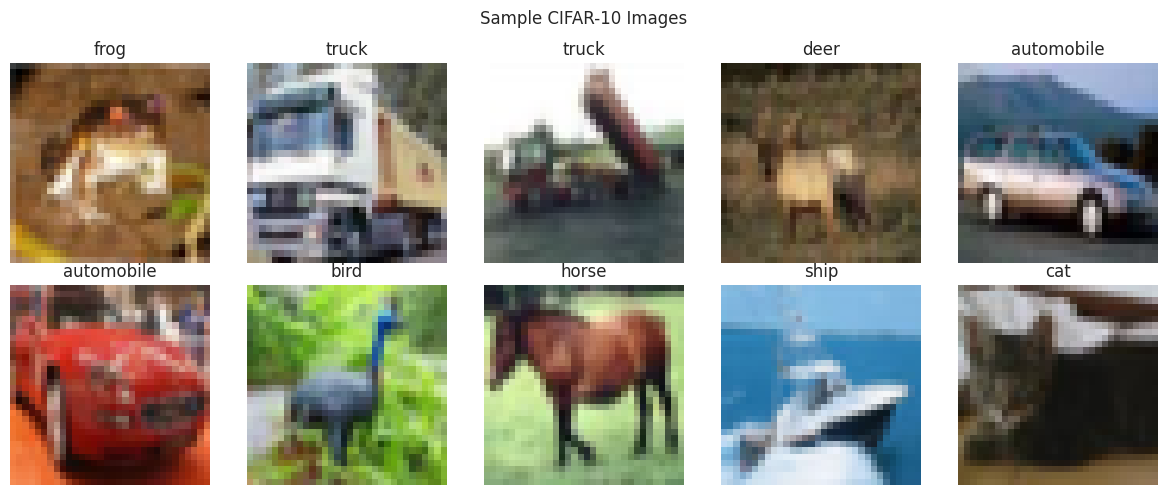

In [7]:
# ---- Ten Sample Images ----
plt.figure(figsize=(12, 5))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train_raw[i])
    plt.title(CLASS_NAMES[y_train_raw[i]])
    plt.axis("off")
plt.suptitle("Sample CIFAR-10 Images")
plt.tight_layout()
plt.show()

In [8]:
def build_transfer_model(base_name="mobilenet", dense_units=128, input_shape=(32, 32, 3)):
    if base_name == "vgg16":
        base_model = VGG16(weights="imagenet", include_top=False, input_shape=input_shape)
    elif base_name == "resnet50":
        base_model = ResNet50(weights="imagenet", include_top=False, input_shape=input_shape)
    elif base_name == "mobilenet":
        base_model = MobileNetV2(weights="imagenet", include_top=False, input_shape=input_shape)
    else:
        raise ValueError(f"Unknown base_name: {base_name}")

    base_model.trainable = False  # freeze the convolutional base

    model = models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dense(dense_units, activation="relu"),
        layers.Dense(10, activation="softmax")
    ])
    return model, base_model


primary_model, primary_base = build_transfer_model(base_name="mobilenet", dense_units=128)
primary_model.summary()

/tmp/ipykernel_1676/359621313.py:7: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(weights="imagenet", include_top=False, input_shape=input_shape)


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 1, 1, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,423,242 (9.24 MB)

 Trainable params: 165,258 (645.54 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [9]:
primary_model.compile(optimizer=Adam(learning_rate=0.001),
                       loss="categorical_crossentropy", metrics=["accuracy"])

start_time = time.time()
history_frozen = primary_model.fit(
    X_train, y_train_cat,
    validation_split=0.1,
    epochs=15,
    batch_size=32,
    verbose=1
)
frozen_training_time = time.time() - start_time
print(f"\nTraining time (frozen base): {frozen_training_time:.2f} seconds")

Epoch 1/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 43s 18ms/step - accuracy: 0.2986 - loss: 1.9379 - val_accuracy: 0.3318 - val_loss: 1.8452
Epoch 2/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.3310 - loss: 1.8398 - val_accuracy: 0.3454 - val_loss: 1.8112
Epoch 3/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.3449 - loss: 1.8014 - val_accuracy: 0.3530 - val_loss: 1.7936
Epoch 4/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.3565 - loss: 1.7730 - val_accuracy: 0.3576 - val_loss: 1.7828
Epoch 5/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.3649 - loss: 1.7502 - val_accuracy: 0.3598 - val_loss: 1.7758
Epoch 6/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.3715 - loss: 1.7315 - val_accuracy: 0.3618 - val_loss: 1.7715
Epoch 7/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.3783 - loss: 1.7151 - val_accuracy: 0.3612 - val_loss: 1.7712
Epoch 8/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.3836 - loss: 1.

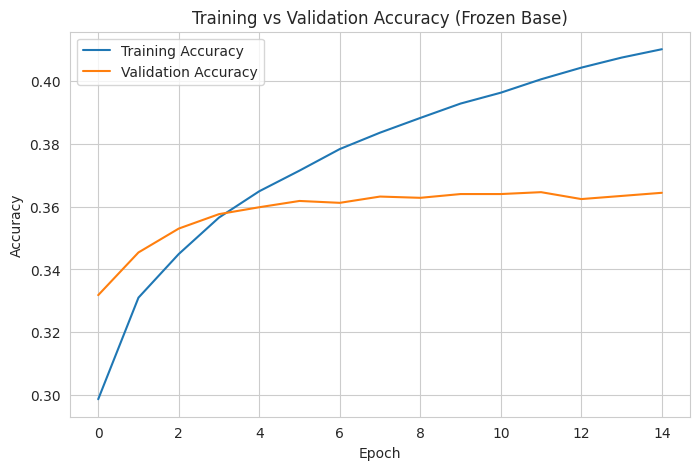

In [10]:
plt.figure(figsize=(8, 5))
plt.plot(history_frozen.history["accuracy"], label="Training Accuracy")
plt.plot(history_frozen.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy (Frozen Base)")
plt.legend()
plt.show()

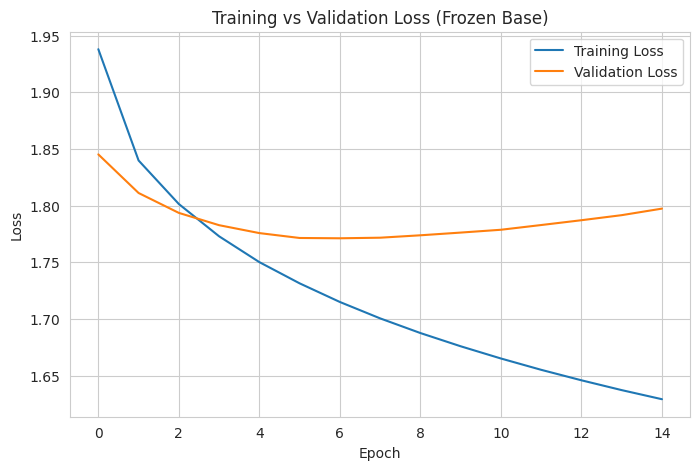

In [11]:
plt.figure(figsize=(8, 5))
plt.plot(history_frozen.history["loss"], label="Training Loss")
plt.plot(history_frozen.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss (Frozen Base)")
plt.legend()
plt.show()

In [12]:
# Accuracy before fine-tuning, on the real test set
pre_finetune_test_loss, pre_finetune_test_acc = primary_model.evaluate(X_test, y_test_cat, verbose=0)
print(f"Test Accuracy BEFORE fine-tuning: {pre_finetune_test_acc:.4f}")

Test Accuracy BEFORE fine-tuning: 0.3531


In [13]:
# Unfreeze the base model, then re-freeze everything except the last block.
primary_base.trainable = True

# Freeze all layers except roughly the last 20 (the final convolutional block for MobileNetV2)
FINE_TUNE_AT = len(primary_base.layers) - 20
for layer in primary_base.layers[:FINE_TUNE_AT]:
    layer.trainable = False

trainable_count = sum(1 for l in primary_base.layers if l.trainable)
print(f"Unfroze the last {trainable_count} of {len(primary_base.layers)} base layers for fine-tuning")

# Recompile with a lower learning rate, since we're now updating pretrained weights
primary_model.compile(optimizer=Adam(learning_rate=0.0001),
                       loss="categorical_crossentropy", metrics=["accuracy"])

start_time = time.time()
history_finetune = primary_model.fit(
    X_train, y_train_cat,
    validation_split=0.1,
    epochs=8,
    batch_size=32,
    verbose=1
)
finetune_training_time = time.time() - start_time
print(f"\nFine-tuning time: {finetune_training_time:.2f} seconds")

Unfroze the last 20 of 154 base layers for fine-tuning
Epoch 1/8
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 34s 16ms/step - accuracy: 0.2994 - loss: 9.6326 - val_accuracy: 0.1902 - val_loss: 5.0940
Epoch 2/8
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.4077 - loss: 2.2067 - val_accuracy: 0.3358 - val_loss: 2.4325
Epoch 3/8
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.4977 - loss: 1.6852 - val_accuracy: 0.4482 - val_loss: 2.0170
Epoch 4/8
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.5480 - loss: 1.5251 - val_accuracy: 0.4990 - val_loss: 2.0378
Epoch 5/8
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.5911 - loss: 1.3356 - val_accuracy: 0.5226 - val_loss: 1.7924
Epoch 6/8
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.6291 - loss: 1.2368 - val_accuracy: 0.5352 - val_loss: 1.7336
Epoch 7/8
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.6736 - loss: 1.0241 - val_accuracy: 0.5358 - val_loss: 1.8586
Epoch 8/8
1407/1407 ━━━━━━━━━━━━━━

Test Accuracy BEFORE fine-tuning: 0.3531
Test Accuracy AFTER fine-tuning : 0.5293
Improvement: 17.62 percentage points


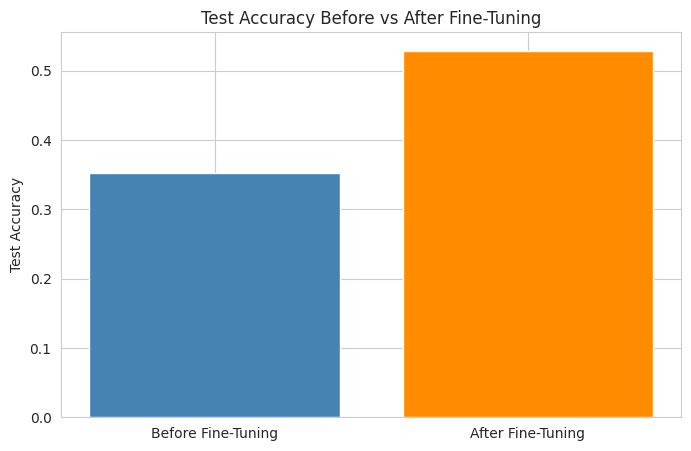

In [14]:
post_finetune_test_loss, post_finetune_test_acc = primary_model.evaluate(X_test, y_test_cat, verbose=0)

print(f"Test Accuracy BEFORE fine-tuning: {pre_finetune_test_acc:.4f}")
print(f"Test Accuracy AFTER fine-tuning : {post_finetune_test_acc:.4f}")
print(f"Improvement: {(post_finetune_test_acc - pre_finetune_test_acc) * 100:.2f} percentage points")

plt.figure(figsize=(8, 5))
plt.bar(["Before Fine-Tuning", "After Fine-Tuning"],
        [pre_finetune_test_acc, post_finetune_test_acc], color=["steelblue", "darkorange"])
plt.ylabel("Test Accuracy")
plt.title("Test Accuracy Before vs After Fine-Tuning")
plt.show()

In [15]:
y_pred_probs = primary_model.predict(X_test, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = y_test_raw

test_accuracy = accuracy_score(y_true, y_pred)
test_precision = precision_score(y_true, y_pred, average="macro")
test_recall = recall_score(y_true, y_pred, average="macro")
test_f1 = f1_score(y_true, y_pred, average="macro")

print(f"Test Accuracy  : {test_accuracy:.4f}")
print(f"Test Precision : {test_precision:.4f}")
print(f"Test Recall    : {test_recall:.4f}")
print(f"Test F1-score  : {test_f1:.4f}")

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

final_train_accuracy = history_finetune.history["accuracy"][-1]
total_params = primary_model.count_params()
print(f"\nFinal Training Accuracy: {final_train_accuracy:.4f}")
print(f"Total Parameters: {total_params:,}")

Test Accuracy  : 0.5293
Test Precision : 0.5381
Test Recall    : 0.5293
Test F1-score  : 0.5274

Classification Report:
              precision    recall  f1-score   support

    airplane       0.64      0.50      0.56      1000
  automobile       0.69      0.57      0.63      1000
        bird       0.43      0.40      0.41      1000
         cat       0.41      0.31      0.35      1000
        deer       0.43      0.56      0.49      1000
         dog       0.51      0.45      0.48      1000
        frog       0.47      0.71      0.56      1000
       horse       0.56      0.52      0.54      1000
        ship       0.57      0.67      0.62      1000
       truck       0.68      0.59      0.63      1000

    accuracy                           0.53     10000
   macro avg       0.54      0.53      0.53     10000
weighted avg       0.54      0.53      0.53     10000


Final Training Accuracy: 0.7131
Total Parameters: 2,423,242


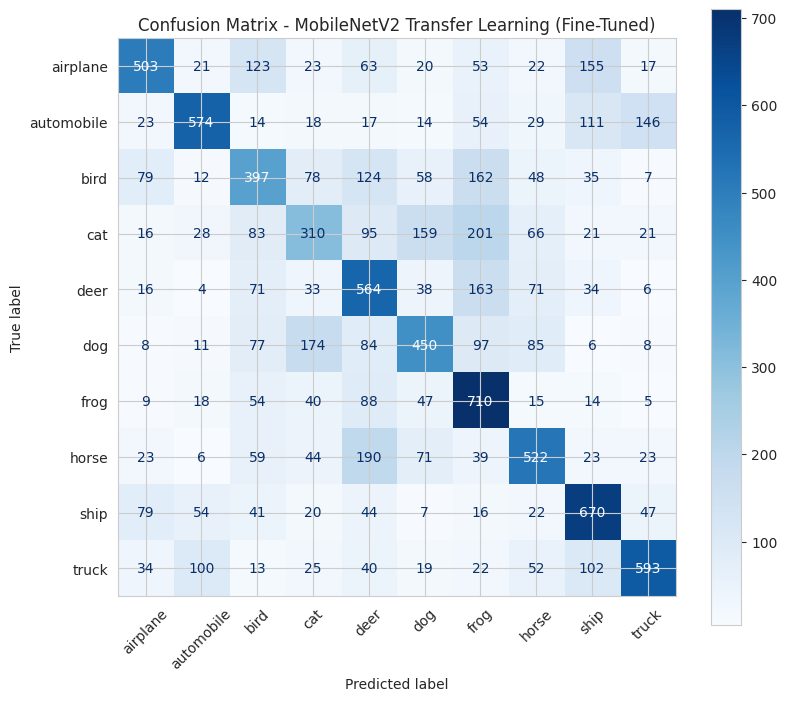

In [16]:
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(9, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
disp.plot(cmap="Blues", xticks_rotation=45, ax=plt.gca())
plt.title("Confusion Matrix - MobileNetV2 Transfer Learning (Fine-Tuned)")
plt.show()

Total misclassified: 4707 out of 10000


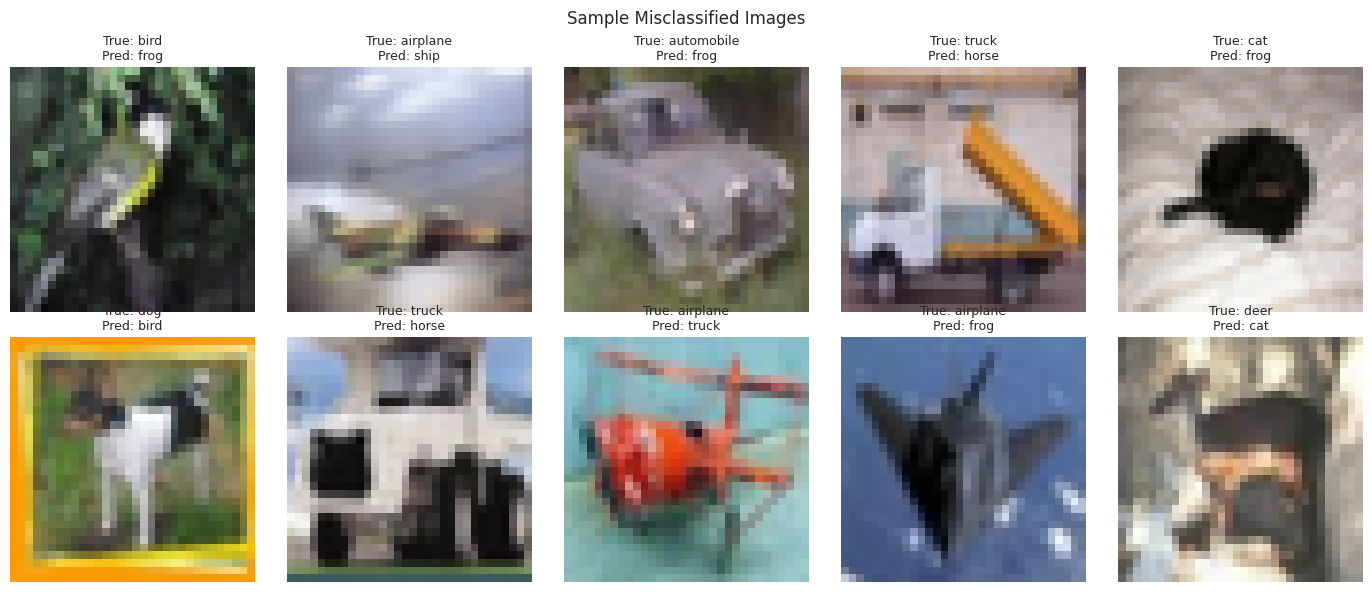

In [17]:
misclassified_idx = np.where(y_pred != y_true)[0]
print(f"Total misclassified: {len(misclassified_idx)} out of {len(y_true)}")

sample_misclassified = np.random.choice(misclassified_idx, size=min(10, len(misclassified_idx)), replace=False)

plt.figure(figsize=(14, 6))
for i, idx in enumerate(sample_misclassified):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_test_raw[idx])
    plt.title(f"True: {CLASS_NAMES[y_true[idx]]}\nPred: {CLASS_NAMES[y_pred[idx]]}", fontsize=9)
    plt.axis("off")
plt.suptitle("Sample Misclassified Images")
plt.tight_layout()
plt.show()

In [18]:
HP_EPOCHS = 5  # reduced purely for speed across multiple hyperparameter combinations

hyperparam_configs = [
    {"name": "Adam, lr=0.001, dense=128",  "optimizer": "adam", "lr": 0.001,  "dense_units": 128},
    {"name": "Adam, lr=0.0001, dense=128", "optimizer": "adam", "lr": 0.0001, "dense_units": 128},
    {"name": "SGD, lr=0.001, dense=128",   "optimizer": "sgd",  "lr": 0.001,  "dense_units": 128},
    {"name": "Adam, lr=0.001, dense=256",  "optimizer": "adam", "lr": 0.001,  "dense_units": 256},
]

hp_results = []
for cfg in hyperparam_configs:
    print(f"\nTraining: {cfg['name']}")
    m, _ = build_transfer_model(base_name="mobilenet", dense_units=cfg["dense_units"])
    opt = Adam(learning_rate=cfg["lr"]) if cfg["optimizer"] == "adam" else SGD(learning_rate=cfg["lr"])
    m.compile(optimizer=opt, loss="categorical_crossentropy", metrics=["accuracy"])

    start = time.time()
    hist = m.fit(X_train, y_train_cat, validation_split=0.1, epochs=HP_EPOCHS, batch_size=32, verbose=0)
    elapsed = time.time() - start
    final_val_acc = hist.history["val_accuracy"][-1]

    hp_results.append({"Configuration": cfg["name"], "Val Accuracy": round(final_val_acc, 4),
                        "Time (s)": round(elapsed, 2)})
    print(f"  -> Val Accuracy: {final_val_acc:.4f} | Time: {elapsed:.2f}s")

hp_results_df = pd.DataFrame(hp_results)
display(hp_results_df)


Training: Adam, lr=0.001, dense=128


/tmp/ipykernel_1676/359621313.py:7: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(weights="imagenet", include_top=False, input_shape=input_shape)


  -> Val Accuracy: 0.3560 | Time: 62.55s

Training: Adam, lr=0.0001, dense=128
  -> Val Accuracy: 0.3268 | Time: 63.68s

Training: SGD, lr=0.001, dense=128
  -> Val Accuracy: 0.2380 | Time: 62.95s

Training: Adam, lr=0.001, dense=256
  -> Val Accuracy: 0.3680 | Time: 70.13s


,Configuration,Val Accuracy,Time (s)
0,"Adam, lr=0.001, dense=128",0.3560,62.55
1,"Adam, lr=0.0001, dense=128",0.3268,63.68
2,"SGD, lr=0.001, dense=128",0.2380,62.95
3,"Adam, lr=0.001, dense=256",0.3680,70.13


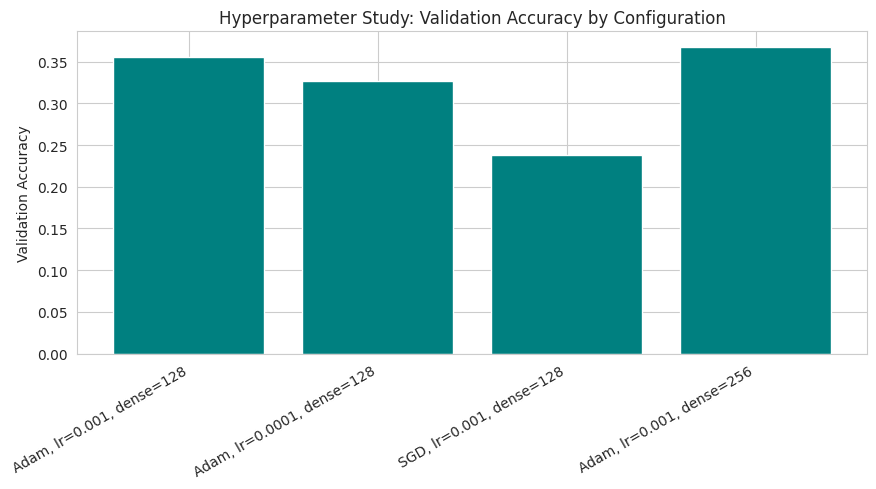

In [19]:
plt.figure(figsize=(9, 5))
plt.bar(hp_results_df["Configuration"], hp_results_df["Val Accuracy"], color="teal")
plt.ylabel("Validation Accuracy")
plt.title("Hyperparameter Study: Validation Accuracy by Configuration")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

In [20]:
performance_summary = pd.DataFrame({
    "Metric": ["Training Accuracy", "Testing Accuracy", "Precision", "Recall", "F1-score",
               "Training Time (Frozen)", "Training Time (Fine-tune)", "Total Parameters"],
    "Value": [round(final_train_accuracy, 4), round(test_accuracy, 4), round(test_precision, 4),
              round(test_recall, 4), round(test_f1, 4), f"{frozen_training_time:.2f}s",
              f"{finetune_training_time:.2f}s", f"{total_params:,}"]
})
display(performance_summary)

,Metric,Value
0,Training Accuracy,0.7131
1,Testing Accuracy,0.5293
2,Precision,0.5381
3,Recall,0.5293
4,F1-score,0.5274
5,Training Time (Frozen),183.39s
6,Training Time (Fine-tune),108.58s
7,Total Parameters,"2,423,242"


In [28]:
ARCH_COMPARISON_EPOCHS = 5  # reduced purely for speed across multiple full-size architectures

architecture_results = {}

# Already have MobileNetV2's fully-trained (fine-tuned) numbers from Tasks 3-5:
architecture_results["MobileNetV2"] = {
    "params": total_params, "accuracy": test_accuracy, "time": frozen_training_time + finetune_training_time
}

for arch_name in ["vgg16", "resnet50"]:
    print(f"\nTraining {arch_name.upper()} (frozen base, {ARCH_COMPARISON_EPOCHS} epochs)...")
    m, _ = build_transfer_model(base_name=arch_name, dense_units=128)
    m.compile(optimizer=Adam(learning_rate=0.001), loss="categorical_crossentropy", metrics=["accuracy"])

    start = time.time()
    m.fit(X_train, y_train_cat, validation_split=0.1, epochs=ARCH_COMPARISON_EPOCHS, batch_size=32, verbose=0)
    elapsed = time.time() - start

    arch_test_loss, arch_test_acc = m.evaluate(X_test, y_test_cat, verbose=0)
    display_name = "VGG16" if arch_name == "vgg16" else "ResNet50"
    architecture_results[display_name] = {
        "params": m.count_params(), "accuracy": arch_test_acc, "time": elapsed
    }
    print(f"  -> Test Accuracy: {arch_test_acc:.4f} | Parameters: {m.count_params():,} | Time: {elapsed:.2f}s")


Training VGG16 (frozen base, 5 epochs)...
  -> Test Accuracy: 0.5882 | Parameters: 14,781,642 | Time: 66.54s

Training RESNET50 (frozen base, 5 epochs)...
  -> Test Accuracy: 0.3516 | Parameters: 23,851,274 | Time: 89.38s


In [29]:
comparison_table = pd.DataFrame({
    "Model": ["LeNet-5*", "AlexNet*", "VGG16", "GoogleNet*", "ResNet50", "MobileNetV2"],
    "Depth": [7, 8, 16, 22, 50, 53],
    "Parameters": ["60K*", "61M*", f"{architecture_results['VGG16']['params']:,}",
                   "6.8M*", f"{architecture_results['ResNet50']['params']:,}",
                   f"{architecture_results['MobileNetV2']['params']:,}"],
    "Accuracy (CIFAR-10, this notebook)": ["--", "--",
                                            f"{architecture_results['VGG16']['accuracy']:.4f}",
                                            "--",
                                            f"{architecture_results['ResNet50']['accuracy']:.4f}",
                                            f"{architecture_results['MobileNetV2']['accuracy']:.4f}"],
    "Training Time (s)": ["--", "--", f"{architecture_results['VGG16']['time']:.1f}",
                          "--", f"{architecture_results['ResNet50']['time']:.1f}",
                          f"{architecture_results['MobileNetV2']['time']:.1f}"]
})
display(comparison_table)
print("\n* Reference values from the original publications / manual Section 8 -- not trained in this notebook.")

,Model,Depth,Parameters,"Accuracy (CIFAR-10, this notebook)",Training Time (s)
0,LeNet-5*,7,60K*,--,--
1,AlexNet*,8,61M*,--,--
2,VGG16,16,"14,781,642",0.5882,66.5
3,GoogleNet*,22,6.8M*,--,--
4,ResNet50,50,"23,851,274",0.3516,89.4
5,MobileNetV2,53,"2,423,242",0.5293,292.0



* Reference values from the original publications / manual Section 8 -- not trained in this notebook.


In [30]:
print("Reusing the Adam vs SGD results from the Hyperparameter Study above:\n")
adam_row = hp_results_df[hp_results_df["Configuration"].str.contains("Adam, lr=0.001, dense=128")]
sgd_row = hp_results_df[hp_results_df["Configuration"].str.contains("SGD")]
display(pd.concat([adam_row, sgd_row]))

Reusing the Adam vs SGD results from the Hyperparameter Study above:



,Configuration,Val Accuracy,Time (s)
0,"Adam, lr=0.001, dense=128",0.356,62.55
2,"SGD, lr=0.001, dense=128",0.238,62.95


In [31]:
print("Reusing the Task 3 (frozen) vs Task 4 (fine-tuned) results:\n")
print(f"Frozen base only    -> Test Accuracy: {pre_finetune_test_acc:.4f} | Training Time: {frozen_training_time:.2f}s")
print(f"After fine-tuning   -> Test Accuracy: {post_finetune_test_acc:.4f} | Training Time: {finetune_training_time:.2f}s (additional)")
print(f"Accuracy improvement from fine-tuning: {(post_finetune_test_acc - pre_finetune_test_acc) * 100:.2f} percentage points")

Reusing the Task 3 (frozen) vs Task 4 (fine-tuned) results:

Frozen base only    -> Test Accuracy: 0.3531 | Training Time: 183.39s
After fine-tuning   -> Test Accuracy: 0.5293 | Training Time: 108.58s (additional)
Accuracy improvement from fine-tuning: 17.62 percentage points


In [32]:
print("Already computed in Task 5:\n")
print(f"Precision (macro): {test_precision:.4f}")
print(f"Recall (macro)   : {test_recall:.4f}")
print(f"F1-score (macro) : {test_f1:.4f}")

Already computed in Task 5:

Precision (macro): 0.5381
Recall (macro)   : 0.5293
F1-score (macro) : 0.5274


In [33]:
lenet_alexnet_resnet = pd.DataFrame({
    "Model": ["LeNet-5", "AlexNet", "ResNet50"],
    "Year": [1998, 2012, 2015],
    "Depth": [7, 8, 50],
    "Parameters": ["60K", "61M", "25.6M"],
    "Key Innovation": ["First practical CNN", "ReLU + Dropout + GPU training", "Residual (skip) connections"]
})
display(lenet_alexnet_resnet)

,Model,Year,Depth,Parameters,Key Innovation
0,LeNet-5,1998,7,60K,First practical CNN
1,AlexNet,2012,8,61M,ReLU + Dropout + GPU training
2,ResNet50,2015,50,25.6M,Residual (skip) connections
